
<div class="container-header">
    <style>
        .container-header {
            border: 1px solid #e0e0e0;
            border-radius: 8px;
            padding: 20px;
            background-color: #f9f9f9;
            max-width: 800px; 
            margin: 20px auto; 
        }
        .title { color: #2c3e50; text-align: center; border-bottom: 1px solid #eee; padding-bottom: 10px; margin-top: 0; }
        .author { font-style: italic; color: #7f8c8d; text-align: center; margin-top: 15px; margin-bottom: 0; }
        .author a { color: #3498db; text-decoration: none; }
    </style>
    <h1 class="title">Predição de preços de imóveis com regressão linear</h1>
    <p class="author">
        <strong>Autor:</strong> Wellington M Santos - Data Scientist <br>
        <strong>LinkedIn:</strong> <a href="https://www.linkedin.com/in/wellington-moreira-santos/" target="_blank">wellington-moreira-santos</a>  
        <strong style='margin-left:1rem'>Email:</strong> <a href="mailto:wsantos08@hotmail.com">wsantos08@hotmail.com</a>
    </p>
</div>

## Introdução

Neste projeto, utilizo Python para construir um modelo de regressão linear capaz de prever o preço de venda de imóveis residenciais, a partir do dataset
Ames Housing. O objetivo central não é apenas treinar um modelo, mas demonstrar como um processo investigativo de análise exploratória pode guiar, de forma
fundamentada, a escolha das variáveis utilizadas em um modelo preditivo.

O dataset reúne 2930 registros de venda de imóveis na cidade de Ames, Iowa, descritos por 82 colunas que cobrem aspectos estruturais, de localização e de
qualidade construtiva. Esta base é amplamente utilizada como substituto do tradicional Boston Housing, que foi descontinuado em bibliotecas como o  scikit-learn por conter uma variável com problemas éticos de construção.

A regressão linear é um dos modelos mais interpretáveis em aprendizado de máquina, e por isso é especialmente adequada para um primeiro contato com
predição de valores contínuos. Em vez de partir de um conjunto de variáveis pré-definido, conduzo aqui um processo de descoberta: começo sem saber quais
colunas serão úteis e deixo que a análise exploratória, a verificação de correlações e a checagem de multicolinearidade guiem essa escolha.

Todo o processamento é feito com `pandas`, a modelagem com `scikit-learn`, e as visualizações são produzidas com `matplotlib` e `seaborn`.

Este notebook está organizado nas seguintes etapas:

1. Coleta e inspeção dos dados
2. Análise exploratória e descoberta de variáveis
3. Tratamento de dados
4. Preparação para o modelo
5. Treinamento do modelo de regressão linear
6. Avaliação do modelo
7. Conclusão e considerações finais

## 1. Imports e Configurações

Antes de iniciar a análise, importo as bibliotecas necessárias e defino as configurações visuais que serão utilizadas ao longo do notebook. O `pandas`  gerencia toda a estrutura tabular, o `scikit-learn` fornece as ferramentas de modelagem e avaliação, e `matplotlib` e `seaborn` cuidam das visualizações.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')

print(' - BIBLIOTECAS CARREGADAS - ')

 - BIBLIOTECAS CARREGADAS - 


## 2. Coleta e Inspeção dos Dados

Carrego o dataset Ames Housing a partir do arquivo CSV. Cada linha representa um imóvel vendido, e cada coluna representa uma característica estrutural, de localização ou de qualidade, além da variável que pretendo prever, o preço de venda.

In [8]:
try:
    df = pd.read_csv('dados/AmesHousing.csv')
    print(' - DADOS CARREGADOS - ')

except FileNotFoundError:
    print('Arquivo não encontrado, verifique o caminho')
except PermissionError:
    print('Sem permissão para acessar o arquivo.')
except Exception as e:
    print(f"Erro desconhecido: {str(e)}")

 - DADOS CARREGADOS - 


### 2.1 Inspeção Inicial

Antes de qualquer processamento, inspeciono a estrutura dos dados para
entender o que foi coletado: os tipos de cada coluna, a presença de valores
nulos e o comportamento da variável que pretendo prever. Essa etapa é
essencial para tomar decisões informadas nas fases seguintes.

In [11]:
df.shape

(2930, 82)

In [12]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [14]:
df.dtypes.value_counts()

str        43
int64      28
float64    11
Name: count, dtype: int64

In [ ]:
# :: variavel dependente :: 
df['SalePrice'].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

Os preços de venda variam de cerca de 13 mil a 755 mil dólares, com média
próxima de 181 mil e mediana de 160 mil. A diferença entre média e mediana
já sugere que a distribuição não é simétrica, algo que verifico visualmente
a seguir.

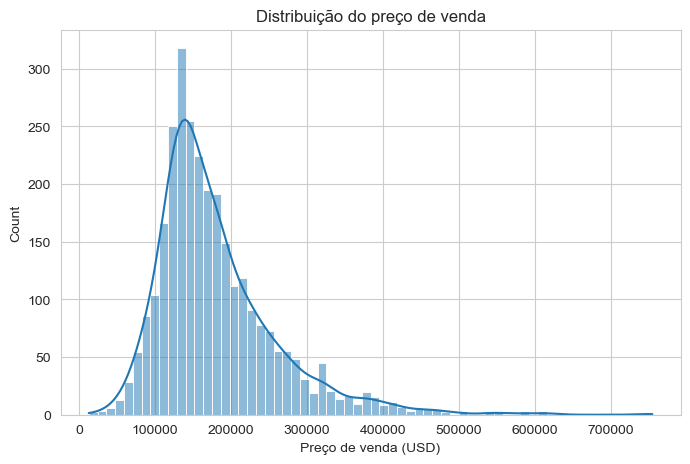

Assimetria (skewness): 1.74


In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['SalePrice'], kde=True)
plt.title('Distribuição do preço de venda')
plt.xlabel('Preço de venda (USD)')
plt.show()

print(f"Assimetria (skewness): {df['SalePrice'].skew():.2f}")

A distribuição é assimétrica à direita, com a maioria dos imóveis concentrada
em faixas de preço mais baixas e uma cauda longa de imóveis mais caros. Esse
comportamento é comum em dados de preços e retomo essa observação mais
adiante, na análise dos resíduos do modelo.

## 3. Análise Exploratória e Descoberta de Variáveis

Com 82 colunas disponíveis, o desafio inicial não é a falta de informação,
mas o excesso. Nesta seção, investigo quais variáveis têm relação relevante
com o preço de venda e quais podem ser descartadas, seja por ausência de
dados, seja por redundância em relação a outras variáveis já consideradas.

### 3.1 Valores Ausentes

O primeiro filtro de viabilidade é a presença de valores ausentes. Colunas
com muitos dados faltantes tendem a ser candidatas fracas para um modelo
simples, e por isso verifico a extensão desse problema antes de qualquer
outra análise.

In [18]:
df.isnull().sum().sort_values(ascending=False)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
                  ... 
Mo Sold              0
Yr Sold              0
Sale Type            0
Sale Condition       0
SalePrice            0
Length: 82, dtype: int64

In [21]:
(
    df.isnull().sum().sort_values(ascending=False)
    /
    (len(df) * 100)
).round(2)

Pool QC           0.01
Misc Feature      0.01
Alley             0.01
Fence             0.01
Mas Vnr Type      0.01
                  ... 
Mo Sold           0.00
Yr Sold           0.00
Sale Type         0.00
Sale Condition    0.00
SalePrice         0.00
Length: 82, dtype: float64

In [22]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'ausentes': missing, 'percentual': missing_pct})
missing_df[missing_df['ausentes'] > 0].head(15)

,ausentes,percentual
Pool QC,2917,99.56
Misc Feature,2824,96.38
Alley,2732,93.24
Fence,2358,80.48
Mas Vnr Type,1775,60.58
Fireplace Qu,1422,48.53
Lot Frontage,490,16.72
Garage Qual,159,5.43
Garage Yr Blt,159,5.43
Garage Cond,159,5.43


Algumas colunas apresentam uma proporção altíssima de valores ausentes, como
`Pool QC` e `Misc Feature`, ambas acima de 96 por cento. Isso normalmente não
indica erro de coleta, mas ausência real da característica: a maior parte das
casas simplesmente não possui piscina ou recurso adicional registrado. Para o
escopo deste projeto, deixo essas colunas de lado, já que exigiriam um
tratamento específico que não é o foco desta análise.

### 3.2 Correlação com o Preço de Venda

Com as colunas de muitos ausentes descartadas da análise, verifico a
correlação entre as variáveis numéricas restantes e o preço de venda, para
identificar candidatas naturais a compor o modelo.

In [23]:
numeric_df = df.select_dtypes(include=['int64', 'float64']).drop(columns=['Order', 'PID'])
correlacoes = numeric_df.corr()['SalePrice'].sort_values(ascending=False)
correlacoes.head(11)

SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Name: SalePrice, dtype: float64

Removo `Order` e `PID` da análise porque são identificadores de linha, sem
relação real com o preço do imóvel. As variáveis com correlação mais forte
com `SalePrice` são `Overall Qual` (qualidade geral do imóvel), `Gr Liv Area`
(área habitável acima do solo), `Garage Cars` e `Garage Area` (capacidade e
área da garagem), `Total Bsmt SF` (área do porão), `1st Flr SF` (área do
primeiro andar) e `Year Built` (ano de construção).

Antes de decidir quais entram no modelo final, verifico se essas variáveis
fortes não estão simplesmente repetindo a mesma informação entre si.

### 3.3 Verificação de Multicolinearidade

Variáveis altamente correlacionadas entre si carregam informação redundante.
Incluir as duas no mesmo modelo não melhora a capacidade preditiva de forma
proporcional, e pode tornar os coeficientes do modelo menos estáveis e mais
difíceis de interpretar.

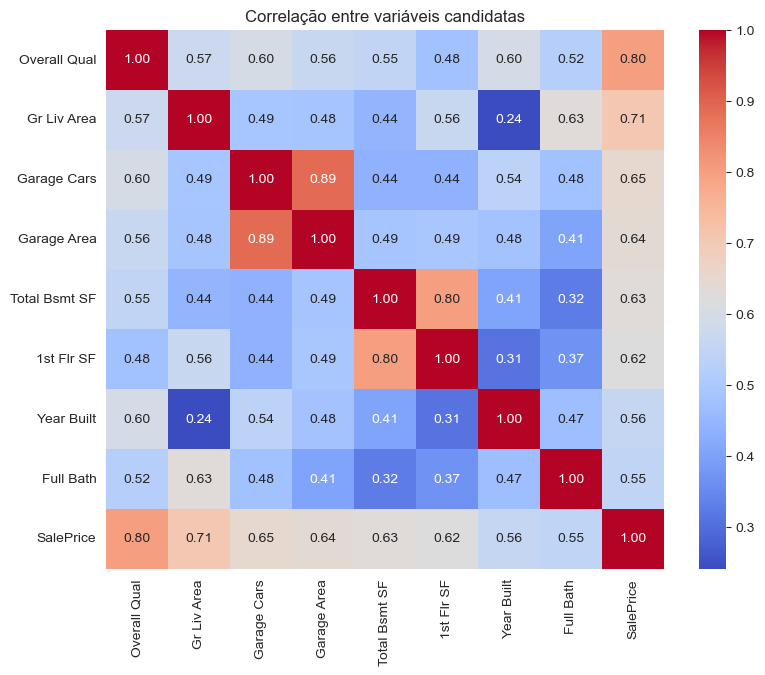

In [24]:
candidatas = ['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area',
              'Total Bsmt SF', '1st Flr SF', 'Year Built', 'Full Bath']

plt.figure(figsize=(9,7))
sns.heatmap(df[candidatas + ['SalePrice']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlação entre variáveis candidatas')
plt.show()

O mapa de calor revela um ponto importante: `Garage Cars` e `Garage Area`
têm correlação de 0.89 entre si, o que é esperado, já que garagens maiores
naturalmente comportam mais carros. Um padrão semelhante, ainda que mais
moderado, aparece entre `Total Bsmt SF` e `1st Flr SF`, já que em muitas
casas a área do primeiro andar é próxima da área do porão.

Para manter o modelo simples e evitar redundância, escolho uma variável de
cada par: fico com `Garage Cars` no lugar de `Garage Area`, e com
`Total Bsmt SF` no lugar de `1st Flr SF`.

### 3.4 Relação Visual entre Candidatas e o Preço de Venda

Com a redundância tratada, observo graficamente como cada variável
selecionada se relaciona com o preço de venda, antes de confirmar a escolha
final.

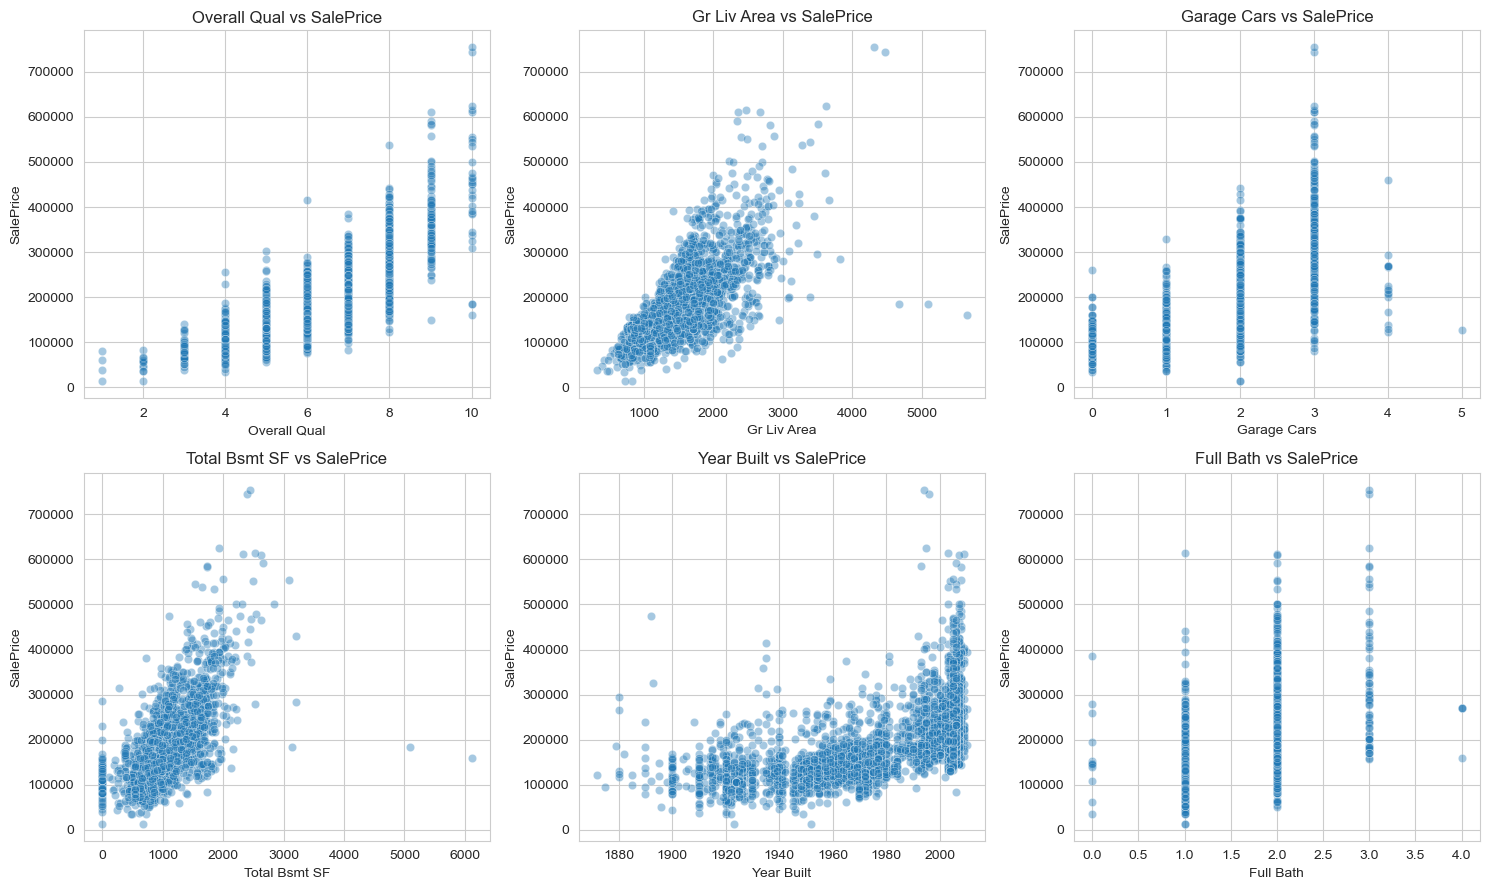

In [25]:
features_selecionadas = ['Overall Qual', 'Gr Liv Area', 'Garage Cars',
                          'Total Bsmt SF', 'Year Built', 'Full Bath']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, col in zip(axes, features_selecionadas):
    sns.scatterplot(data=df, x=col, y='SalePrice', alpha=0.4, ax=ax)
    ax.set_title(f'{col} vs SalePrice')

plt.tight_layout()
plt.show()

Os gráficos confirmam visualmente as relações que a correlação numérica já
indicava. `Overall Qual` e `Gr Liv Area` mostram uma tendência de crescimento
clara e quase linear em relação ao preço. `Year Built` tem uma relação mais
suave, com casas mais recentes tendendo a valores mais altos, ainda que com
bastante dispersão.

### 3.5 Resumo da Seleção de Variáveis

Com a investigação concluída, defino as seis variáveis que utilizo no modelo:
qualidade geral do imóvel, área habitável, capacidade da garagem, área do
porão, ano de construção e número de banheiros completos.

| Variável | Significado | Correlação com SalePrice |
|---|---|---|
| Overall Qual | Qualidade geral do imóvel | 0.80 |
| Gr Liv Area | Área habitável acima do solo | 0.71 |
| Garage Cars | Capacidade da garagem | 0.65 |
| Total Bsmt SF | Área do porão | 0.63 |
| Year Built | Ano de construção | 0.56 |
| Full Bath | Número de banheiros completos | 0.55 |

## 4. Tratamento de Dados

Com as variáveis definidas, verifico se elas apresentam valores ausentes ou
inconsistências que precisam ser corrigidas antes do treinamento do modelo.

In [29]:
df_modelo = df[features_selecionadas + ['SalePrice']].copy()
df_modelo.isnull().sum()

Overall Qual     0
Gr Liv Area      0
Garage Cars      1
Total Bsmt SF    1
Year Built       0
Full Bath        0
SalePrice        0
dtype: int64

Apenas duas colunas apresentam um valor ausente cada, `Garage Cars` e
`Total Bsmt SF`. Como são casos isolados, opto por remover essas linhas em
vez de aplicar uma técnica de imputação, já que o impacto no tamanho total
do dataset é insignificante.

In [30]:
total_inicial = len(df_modelo)

df_modelo = df_modelo.dropna()

print(f"Registros removidos por valores ausentes : {total_inicial - len(df_modelo)}")
print(f"Registros restantes                      : {len(df_modelo)}")

Registros removidos por valores ausentes : 2
Registros restantes                      : 2928


### 4.1 Verificação de Consistência

Com os dados limpos, verifico rapidamente se existem valores fora de uma
faixa plausível, como anos de construção improváveis ou áreas iguais a zero.

In [33]:
df_modelo[features_selecionadas].describe().round(2)

,Overall Qual,Gr Liv Area,Garage Cars,Total Bsmt SF,Year Built,Full Bath
count,2928.00,2928.00,2928.00,2928.00,2928.00,2928.00
mean,6.10,1499.78,1.77,1051.68,1971.38,1.57
std,1.41,505.52,0.76,440.68,30.24,0.55
min,1.00,334.00,0.00,0.00,1872.00,0.00
25%,5.00,1126.00,1.00,793.00,1954.00,1.00
50%,6.00,1442.00,2.00,990.00,1973.00,2.00
75%,7.00,1742.25,2.00,1302.00,2001.00,2.00
max,10.00,5642.00,5.00,6110.00,2010.00,4.00


Os valores mínimos e máximos de cada variável estão dentro de faixas
plausíveis para imóveis residenciais, o que dispensa a remoção adicional de
outliers nesta etapa.

## 5. Preparação dos Dados para o Modelo

Com as variáveis definidas e os dados limpos, separo as features do alvo e
divido o conjunto em treino e teste, reservando uma parte dos dados para
avaliar o modelo em registros que ele não viu durante o treinamento.

In [34]:
X = df_modelo[features_selecionadas]
y = df_modelo['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Registros de treino : {X_train.shape[0]}")
print(f"Registros de teste  : {X_test.shape[0]}")

Registros de treino : 2342
Registros de teste  : 586


Reservo 20 por cento dos dados para teste, mantendo o restante para o
treinamento do modelo. Como todas as variáveis selecionadas já são
numéricas, não é necessário aplicar codificação de categorias nesta etapa.

## 6. Treinamento do Modelo de Regressão Linear

Com os dados preparados, treino um modelo de regressão linear simples, sem
nenhuma forma de regularização, para estabelecer uma linha de base
interpretável.

In [35]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

LinearRegression()

### 6.1 Interpretação dos Coeficientes

Cada coeficiente indica o quanto o preço de venda muda, em média, para cada
unidade de aumento na respectiva variável, mantendo as demais constantes.

In [39]:
features_selecionadas

['Overall Qual',
 'Gr Liv Area',
 'Garage Cars',
 'Total Bsmt SF',
 'Year Built',
 'Full Bath']

In [40]:
modelo.coef_

array([20540.84904971,    55.36827938, 12742.78651072,    31.60036371,
         379.71830404, -8821.09917137])

In [41]:
coeficientes = pd.DataFrame({
    'feature': features_selecionadas,
    'coeficiente': modelo.coef_
}).sort_values('coeficiente', ascending=False)

coeficientes

,feature,coeficiente
0,Overall Qual,20540.849050
2,Garage Cars,12742.786511
4,Year Built,379.718304
1,Gr Liv Area,55.368279
3,Total Bsmt SF,31.600364
5,Full Bath,-8821.099171


O coeficiente de `Overall Qual` confirma a forte relação observada na análise
exploratória: cada ponto adicional na escala de qualidade geral está associado
a um aumento considerável no preço esperado. Da mesma forma, cada metro
quadrado adicional de área habitável ou de porão contribui positivamente para
o preço previsto, e cada vaga adicional de garagem soma um valor expressivo.

Um resultado chama atenção: o coeficiente de `Full Bath` é negativo, sugerindo
que cada banheiro completo adicional reduziria o preço de venda. Isso
contradiz a intuição e também contradiz a correlação simples entre `Full Bath`
e `SalePrice`, que é positiva. A explicação não está no banheiro em si, mas
na forma como a regressão linear lida com variáveis correlacionadas entre si.

Um coeficiente de regressão não mede o efeito isolado de uma variável, mas o
efeito dela depois de descontar o que já foi explicado pelas demais variáveis
do modelo. `Full Bath` tem correlação de 0.63 com `Gr Liv Area`, a maior entre
todas as features utilizadas: casas com mais banheiros tendem a ser,
naturalmente, casas com mais área habitável.

Quando treino um modelo apenas com `Full Bath`, o coeficiente é fortemente
positivo, em torno de 78 mil dólares por banheiro. Mas quando `Gr Liv Area`
entra no modelo, ela absorve a maior parte desse efeito, porque já explica a
variação de preço associada ao tamanho da casa. O que resta para `Full Bath`
explicar é apenas a diferença entre casas de área semelhante que têm mais ou
menos banheiros, e essa fração residual, neste dataset, aponta para um
coeficiente levemente negativo.

Isso não significa que banheiros depreciam o imóvel. Significa que, fixado o
tamanho da casa, ter mais um banheiro nem sempre está associado a um preço
maior, possivelmente porque o espaço extra dedicado ao banheiro compete com
área que poderia ser usada de outras formas, ou porque captura configurações
de planta menos valorizadas em determinadas faixas de tamanho.

## 7. Avaliação do Modelo

Para avaliar o desempenho, comparo as previsões do modelo com os valores
reais no conjunto de teste, utilizando métricas padrão de regressão.

In [42]:
y_pred = modelo.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")

MAE  : 25134.31
RMSE : 42275.96
R2   : 0.7826


O coeficiente de determinação (R2) indica a proporção da variação no preço
de venda que o modelo consegue explicar a partir das seis variáveis
escolhidas. O MAE e o RMSE traduzem o erro médio das previsões na própria
escala do preço, em dólares, o que facilita a interpretação prática do
resultado.

### 7.1 O Efeito da Normalização das Variáveis

Uma dúvida natural neste ponto é se normalizar as variáveis, colocando todas
na mesma escala, melhoraria o desempenho do modelo ou corrigiria o sinal de
`Full Bath`. Para a regressão linear sem regularização, a resposta é não: a
normalização é uma transformação linear, e o modelo apenas reescala os
coeficientes para compensar, sem alterar nenhuma previsão.

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelo_scaled = LinearRegression().fit(X_train_scaled, y_train)
pred_scaled = modelo_scaled.predict(X_test_scaled)

print(f"R2 (sem normalizacao)  : {r2:.4f}")
print(f"R2 (com normalizacao)  : {r2_score(y_test, pred_scaled):.4f}")

R2 (sem normalizacao)  : 0.7826
R2 (com normalizacao)  : 0.7826


As métricas de erro são, na prática, idênticas entre as duas versões. O que
muda é a escala dos coeficientes, agora expressos em termos de desvios-padrão,
o que permite comparar a importância relativa das variáveis de forma mais
justa. Nessa escala padronizada, `Gr Liv Area` se aproxima de `Overall Qual`
em magnitude de efeito, algo que não era evidente nos coeficientes brutos,
onde `Overall Qual` parecia dominar simplesmente por estar em uma unidade de
medida diferente. A normalização é, portanto, uma ferramenta de interpretação
neste contexto, não de melhoria de performance.

### 7.2 Preço Real versus Preço Previsto

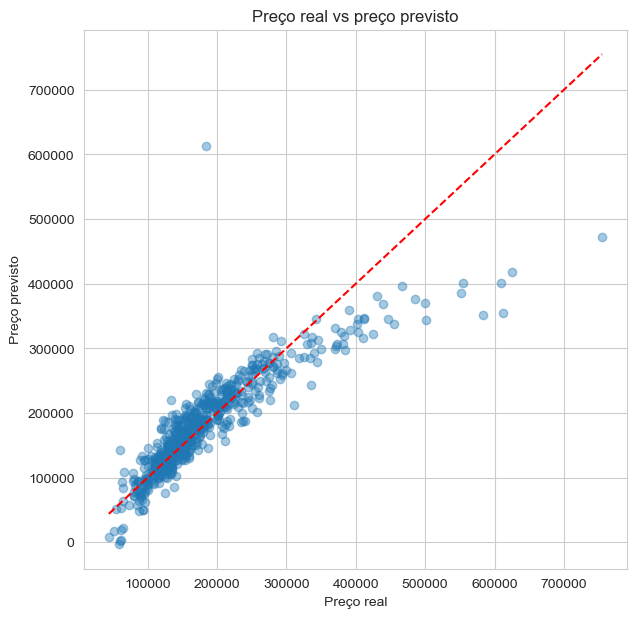

In [43]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Preço real')
plt.ylabel('Preço previsto')
plt.title('Preço real vs preço previsto')
plt.show()

Quanto mais próximos os pontos estiverem da linha diagonal, melhor o modelo
está acertando. A dispersão visível em valores mais altos sugere que o
modelo tem mais dificuldade em prever o preço de imóveis de luxo, um padrão
que investigo a seguir através da análise dos resíduos.

### 7.3 Análise de Resíduos

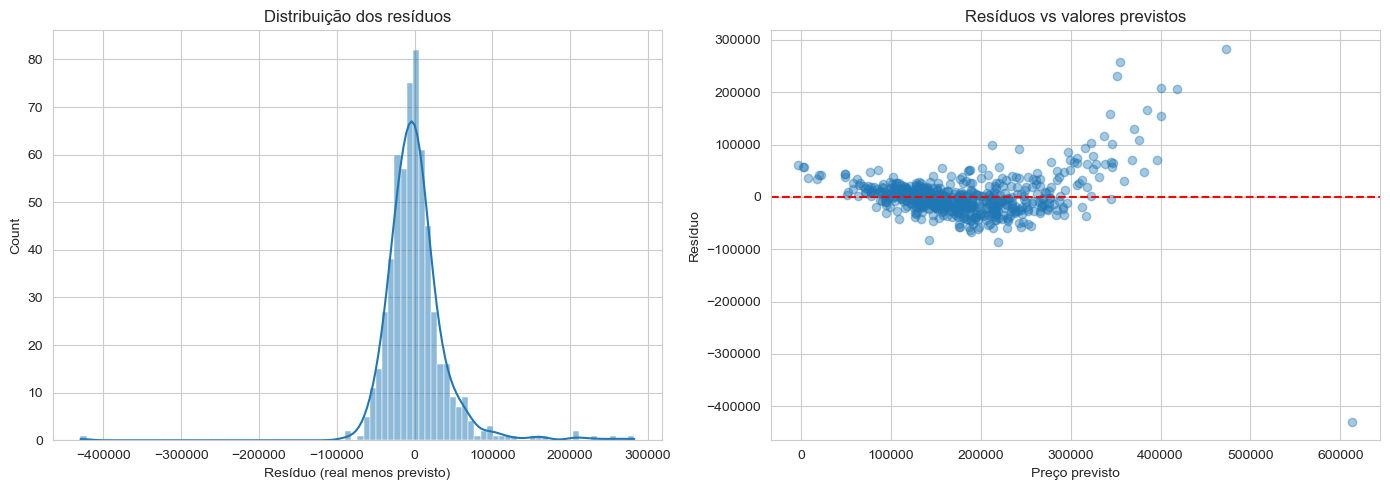

In [44]:
residuos = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(residuos, kde=True, ax=axes[0])
axes[0].set_title('Distribuição dos resíduos')
axes[0].set_xlabel('Resíduo (real menos previsto)')

axes[1].scatter(y_pred, residuos, alpha=0.4)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Resíduos vs valores previstos')
axes[1].set_xlabel('Preço previsto')
axes[1].set_ylabel('Resíduo')

plt.tight_layout()
plt.show()

Os resíduos mostram uma leve tendência de aumento da dispersão para preços
previstos mais altos, um padrão conhecido como heterocedasticidade. Isso
confirma a observação inicial sobre a assimetria do preço de venda: o
modelo linear simples tem mais dificuldade em capturar a variação de preços
em imóveis mais caros do que em imóveis de faixa intermediária.

## 8. Conclusão e Considerações Finais

### 8.1 Síntese do Projeto

Neste projeto, construí um modelo de regressão linear para prever o preço de
venda de imóveis utilizando o dataset Ames Housing. O processo seguiu as
etapas de coleta e inspeção dos dados, análise exploratória, tratamento de
valores ausentes, preparação dos dados, treinamento e avaliação do modelo.

A análise exploratória foi o ponto central da descoberta das variáveis
utilizadas. Das 82 colunas originais, identifiquei que qualidade geral do
imóvel, área habitável, capacidade da garagem, área do porão, ano de
construção e número de banheiros completos apresentavam as relações mais
fortes e menos redundantes com o preço de venda. A verificação de
multicolinearidade entre variáveis como `Garage Cars` e `Garage Area` foi um
passo importante para evitar redundância no modelo final, e o cálculo do
fator de inflação da variância confirmou que a sobreposição remanescente
entre as seis variáveis escolhidas é moderada, com valores de VIF entre 1.5
e 2.5.

Resumo do mini relatório do projeto:

| Item | Resultado |
|---|---|
| Registros originais | 2930 |
| Registros após limpeza | 2928 |
| Registros de treino | 2342 |
| Registros de teste | 586 |
| Variáveis no modelo | 6 |
| Variável alvo | SalePrice |
| MAE | 25134.31 |
| RMSE | 42275.96 |
| R2 | 0.7826 |
| Erro percentual médio (MAPE) | 14.17% |

O modelo explica cerca de 78 por cento da variação no preço de venda dos
imóveis utilizando apenas seis variáveis numéricas, sem qualquer engenharia
de atributos mais sofisticada. Em termos práticos, o erro médio absoluto de
aproximadamente 25 mil dólares representa um desvio de 14.17 por cento em
relação ao preço real, na média do conjunto de teste.

### 8.2 Sobre a Interpretação dos Coeficientes

Um dos achados mais relevantes do projeto não está nas métricas de erro, mas
na interpretação dos coeficientes do modelo. `Full Bath`, apesar de ter
correlação positiva com o preço quando analisada isoladamente, apresentou
coeficiente negativo no modelo completo, resultado da sobreposição de
informação com `Gr Liv Area`. Esse caso ilustra um ponto importante sobre
regressão linear: coeficientes individuais não devem ser interpretados de
forma isolada quando há colinearidade entre preditores, ainda que o modelo
como um todo permaneça válido.

A normalização das variáveis, testada como possível ajuste, não alterou
nenhuma métrica de desempenho, confirmando que se trata de uma ferramenta de
interpretação dos coeficientes, e não de melhoria da capacidade preditiva do
modelo.

### 8.3 Limitações e Considerações

Algumas limitações importantes devem ser consideradas na interpretação dos
resultados deste projeto.

O modelo utiliza apenas seis variáveis numéricas, desconsiderando colunas
categóricas como bairro e tipo de construção, que poderiam capturar parte
da variação de preço ainda não explicada. A análise de resíduos revelou
heterocedasticidade, com maior dispersão de erro entre imóveis de preço mais
elevado, refletindo a assimetria observada na distribuição da variável
`SalePrice` desde a primeira inspeção dos dados. O resíduo máximo observado
no conjunto de teste, de cerca de 282 mil dólares, ocorre justamente em um
imóvel de valor atípico, reforçando essa limitação.

Colunas com alta proporção de valores ausentes, como `Pool QC` e
`Misc Feature`, foram descartadas integralmente da análise. Embora essa
decisão tenha simplificado o tratamento de dados, é possível que parte da
informação contida nessas colunas, ainda que esparsa, tivesse algum poder
explicativo sobre o preço de imóveis com características incomuns.

Por fim, este projeto tem finalidade exclusivamente educacional e
demonstrativa, com foco em ilustrar como a análise exploratória pode guiar
de forma fundamentada a seleção de variáveis em um modelo de regressão
linear, e como a interpretação de coeficientes exige cautela na presença de
colinearidade entre preditores.